# Clustering Analysis

## Objective

The objective of this analysis is to perform unsupervised clustering on the dataset to identify natural groupings within the data.

The following clustering algorithms will be implemented:

1. **K-Means Clustering**
2. **Agglomerative Hierarchical Clustering**

The clustering models will be evaluated using the following mandatory metrics:

- **Silhouette Score**
- **Davies-Bouldin Index**
- **Calinski-Harabasz Index**

The **Elbow Curve** will be used to help select the optimal number of clusters for K-Means. For Agglomerative Hierarchical Clustering, different linkage strategies will be compared using a **Dendrogram**.

Finally, **Principal Component Analysis (PCA)** with two principal components will be used to visualize the resulting clusters.

> **Note:** Clustering is an unsupervised learning technique. Ground-truth labels, if available in the dataset, will not be used during model fitting. They may only be used afterward for interpretation or validation.

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

## 3. Dataset Loading and Initial Inspection

The dataset is loaded and examined to understand its structure, feature types, missing values, and dimensions before performing clustering.

Since clustering is an unsupervised learning task, the ground-truth target variable, if present, will not be used for fitting the clustering models.

In [2]:
# Load the dataset

data = pd.read_csv("../data/Bengaluru_House_Data.csv")

print("Dataset Shape:", data.shape)

data.head()

Dataset Shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
# Display dataset information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [4]:
# Check for missing values

missing_values = data.isnull().sum()

missing_values[missing_values > 0]

location       1
size          16
society     5502
bath          73
balcony      609
dtype: int64

In [5]:
# Statistical summary of numerical features

data.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


### Observation

- The dataset contains **13,320 records and 9 columns**.
- The dataset contains both numerical and categorical features.
- The numerical columns are `bath`, `balcony`, and `price`.
- The columns `area_type`, `availability`, `location`, `size`, and `society` are categorical.
- The `total_sqft` column is stored as an object and therefore requires preprocessing before it can be used as a numerical feature.
- Missing values are present in `location`, `size`, `society`, `bath`, and `balcony`, with `society` containing the largest number of missing values.
- Since clustering algorithms operate on numerical feature representations, the categorical and non-numeric features must be appropriately transformed before clustering.
- The `price` column represents the property price and may be used as a feature for identifying groups of properties. No ground-truth clustering labels are present in this dataset.

## 4. Data Cleaning and Feature Preparation

Before applying clustering algorithms, the dataset must be converted into a numerical representation suitable for distance-based clustering.

The preprocessing steps include:

1. Handling missing values.
2. Converting `total_sqft` into a numerical representation.
3. Extracting the number of bedrooms from the `size` column.
4. Encoding relevant categorical variables.
5. Selecting the final clustering features.
6. Standardizing the features before applying clustering algorithms.

Ground-truth labels, if any, will not be included in the clustering feature matrix.

In [6]:
# Convert total_sqft into a numerical feature

def convert_total_sqft(value):
    try:
        if '-' in value:
            values = value.split('-')
            return (float(values[0]) + float(values[1])) / 2
        else:
            return float(value)
    except:
        return np.nan


data['total_sqft_num'] = data['total_sqft'].apply(convert_total_sqft)

print("Missing values after conversion:")
print(data['total_sqft_num'].isnull().sum())

data[['total_sqft', 'total_sqft_num']].head(10)

Missing values after conversion:
46


,total_sqft,total_sqft_num
0,1056,1056.0
1,2600,2600.0
2,1440,1440.0
3,1521,1521.0
4,1200,1200.0
5,1170,1170.0
6,2732,2732.0
7,3300,3300.0
8,1310,1310.0
9,1020,1020.0


### Observation

- A new numerical feature, `total_sqft_num`, was created from the original `total_sqft` column.
- Standard numerical values were successfully converted to floating-point values.
- For entries containing a range of square-foot values, the midpoint of the range was used as the numerical representation.
- **46 records** could not be converted and are therefore represented as missing values (`NaN`).
- The original `total_sqft` column is retained for reference, while `total_sqft_num` will be considered for clustering.

In [7]:
# Extract the number of bedrooms from the size column

data['bhk'] = data['size'].str.extract(r'(\d+)')[0].astype(float)

print("Missing values in bhk:", data['bhk'].isnull().sum())

data[['size', 'bhk']].head(10)

Missing values in bhk: 16


,size,bhk
0,2 BHK,2.0
1,4 Bedroom,4.0
2,3 BHK,3.0
3,3 BHK,3.0
4,2 BHK,2.0
5,2 BHK,2.0
6,4 BHK,4.0
7,4 BHK,4.0
8,3 BHK,3.0
9,6 Bedroom,6.0


### Observation

- A new numerical feature, `bhk`, was extracted from the `size` column.
- The extraction successfully converts values such as `2 BHK` and `4 Bedroom` into their corresponding numerical bedroom counts.
- **16 records** have missing `bhk` values because their `size` information could not be extracted.
- The new `bhk` feature will be used as a numerical property characteristic for clustering.

### 4.3 Handling Missing Numerical Values

Missing values in the numerical clustering features are handled using median imputation.

The median is used because property-related numerical variables can contain extreme values, and the median is less sensitive to such outliers than the mean.

In [9]:
# Fill missing numerical values using the median

numeric_features = ['total_sqft_num', 'bhk', 'bath', 'balcony', 'price']

for column in numeric_features:
    data[column] = data[column].fillna(data[column].median())

print("Missing values after median imputation:")
print(data[numeric_features].isnull().sum())

Missing values after median imputation:
total_sqft_num    0
bhk               0
bath              0
balcony           0
price             0
dtype: int64


### 4.4 Selection of Clustering Features

The following numerical features are selected for clustering:

- `total_sqft_num`
- `bhk`
- `bath`
- `balcony`
- `price`

These features represent important quantitative characteristics of the properties.

The categorical columns are not included in the clustering feature matrix because directly encoding high-cardinality fields such as `location` and `society` could disproportionately influence distance-based clustering.

The selected features will be standardized before applying K-Means and Agglomerative Hierarchical Clustering.

In [10]:
# Select numerical features for clustering

cluster_features = [
    'total_sqft_num',
    'bhk',
    'bath',
    'balcony',
    'price'
]

X_cluster = data[cluster_features].copy()

print("Clustering feature shape:", X_cluster.shape)
X_cluster.head()

Clustering feature shape: (13320, 5)


,total_sqft_num,bhk,bath,balcony,price
0,1056.0,2.0,2.0,1.0,39.07
1,2600.0,4.0,5.0,3.0,120.00
2,1440.0,3.0,2.0,3.0,62.00
3,1521.0,3.0,3.0,1.0,95.00
4,1200.0,2.0,2.0,1.0,51.00


### Observation

The clustering dataset contains **13,320 observations and 5 numerical features**. These features capture property size, bedroom count, bathroom count, balcony count, and price. The resulting feature matrix contains only numerical variables and is therefore suitable for subsequent feature scaling and clustering.

### 4.5 Feature Scaling

The selected numerical features have different ranges and scales. Since both K-Means and Agglomerative Hierarchical Clustering are distance-based algorithms, features with larger numerical ranges could disproportionately influence the clustering results.

Therefore, StandardScaler is used to standardize the clustering features.

After standardization, each feature has approximately zero mean and unit standard deviation.

In [11]:
# Standardize the clustering features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=cluster_features,
    index=X_cluster.index
)

print("Scaled feature matrix shape:", X_scaled.shape)

X_scaled.head()

Scaled feature matrix shape: (13320, 5)


,total_sqft_num,bhk,bath,balcony,price
0,-0.406564,-0.621234,-0.514538,-0.751371,-0.493372
1,0.842293,0.924164,1.726436,1.739175,0.049906
2,-0.095967,0.151465,-0.514538,1.739175,-0.339444
3,-0.030451,0.151465,0.232453,-0.751371,-0.117917
4,-0.290090,-0.621234,-0.514538,-0.751371,-0.413286


### Observation

The selected clustering features were standardized using `StandardScaler`. The resulting feature matrix contains **13,320 observations and 5 standardized features**.

Standardization ensures that differences in the original numerical scales do not cause any single feature to disproportionately influence the distance calculations used by the clustering algorithms.

## 5. K-Means Clustering

K-Means clustering partitions the observations into a predefined number of clusters. Each observation is assigned to the cluster whose centroid is closest to it.

The Elbow Method is used to determine a suitable number of clusters. It evaluates the K-Means inertia for different values of `k`. Inertia represents the within-cluster sum of squared distances between observations and their assigned cluster centroids.

A suitable value of `k` is identified by looking for an elbow point where increasing the number of clusters produces diminishing reductions in inertia.

### 5.1 Elbow Method

In [12]:
# Calculate K-Means inertia for different numbers of clusters

inertia_values = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

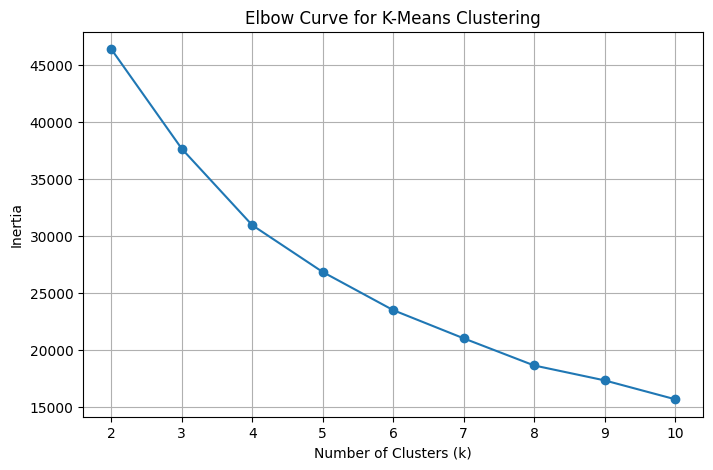

In [13]:
# Plot the Elbow Curve

plt.figure(figsize=(8, 5))

plt.plot(k_values, inertia_values, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Curve for K-Means Clustering")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [14]:
# Display the inertia values for each number of clusters

elbow_results = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertia_values
})

elbow_results

,k,inertia
0,2,46362.517293
1,3,37636.578365
2,4,30940.870657
3,5,26838.909343
4,6,23497.350908
5,7,21026.629631
6,8,18648.424338
7,9,17341.640501
8,10,15688.361809


### Observation

The Elbow Curve shows a substantial reduction in inertia as the number of clusters increases from 2 to 5. After approximately **k = 5**, the reduction in inertia becomes comparatively smaller, indicating diminishing returns from adding further clusters.

Therefore, **k = 5** is selected as the initial number of clusters for the K-Means model.

### 5.2 Final K-Means Model

Based on the Elbow Method, K-Means is fitted using **5 clusters**.

In [15]:
# Fit the final K-Means model with the selected number of clusters

optimal_k = 5

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X_scaled)

print("Number of clusters:", optimal_k)
print("Cluster labels:", np.unique(kmeans_labels))

Number of clusters: 5
Cluster labels: [0 1 2 3 4]


In [16]:
# Display the number of observations in each cluster

cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()

cluster_counts

0    5252
1    1811
2    5791
3     421
4      45
Name: count, dtype: int64

### 5.3 K-Means Evaluation

The K-Means clustering results are evaluated using three mandatory clustering metrics:

- **Silhouette Score:** Measures how well each observation fits within its assigned cluster compared with other clusters. Higher values indicate better-defined clusters.
- **Davies-Bouldin Index:** Measures the average similarity between each cluster and its most similar cluster. Lower values indicate better separation.
- **Calinski-Harabasz Index:** Compares between-cluster dispersion with within-cluster dispersion. Higher values generally indicate better-defined clusters.

In [17]:
# Calculate mandatory clustering metrics for K-Means

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_calinski_harabasz = calinski_harabasz_score(X_scaled, kmeans_labels)

print("K-Means Clustering Metrics")
print("-" * 30)
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {kmeans_calinski_harabasz:.4f}")

K-Means Clustering Metrics
------------------------------
Silhouette Score: 0.3982
Davies-Bouldin Index: 1.0462
Calinski-Harabasz Index: 4931.4515


### Observation

The K-Means model with **5 clusters** produced the following evaluation results:

- **Silhouette Score:** 0.3982
- **Davies-Bouldin Index:** 1.0462
- **Calinski-Harabasz Index:** 4931.4515

The Silhouette Score indicates a moderate level of cluster separation and cohesion. The Davies-Bouldin Index provides a measure of similarity between clusters, while the Calinski-Harabasz Index indicates the degree of separation relative to within-cluster dispersion.

These metrics provide a baseline for comparing K-Means with Agglomerative Hierarchical Clustering later in the analysis.

## 6. Agglomerative Hierarchical Clustering

Agglomerative Hierarchical Clustering is a bottom-up clustering approach that initially treats each observation as an individual cluster and progressively merges the closest clusters.

Different linkage strategies determine how the distance between clusters is calculated. The linkage strategies considered in this analysis are:

- **Ward:** Minimizes the increase in within-cluster variance after merging clusters.
- **Complete:** Uses the maximum distance between observations in two clusters.
- **Average:** Uses the average distance between observations in two clusters.
- **Single:** Uses the minimum distance between observations in two clusters.

A dendrogram is used to visualize the hierarchical merging process and compare the linkage structures.

### 6.1 Dendrogram and Linkage Comparison

A representative sample of the standardized observations is used to construct the dendrograms so that the hierarchical structure can be visualized clearly without generating an excessively large plot.

The sample is used only for visualization; the final Agglomerative Clustering model will be evaluated using the complete dataset.

In [18]:
# Select a representative sample for dendrogram visualization

dendrogram_sample = X_scaled.sample(
    n=500,
    random_state=42
)

print("Dendrogram sample shape:", dendrogram_sample.shape)

Dendrogram sample shape: (500, 5)


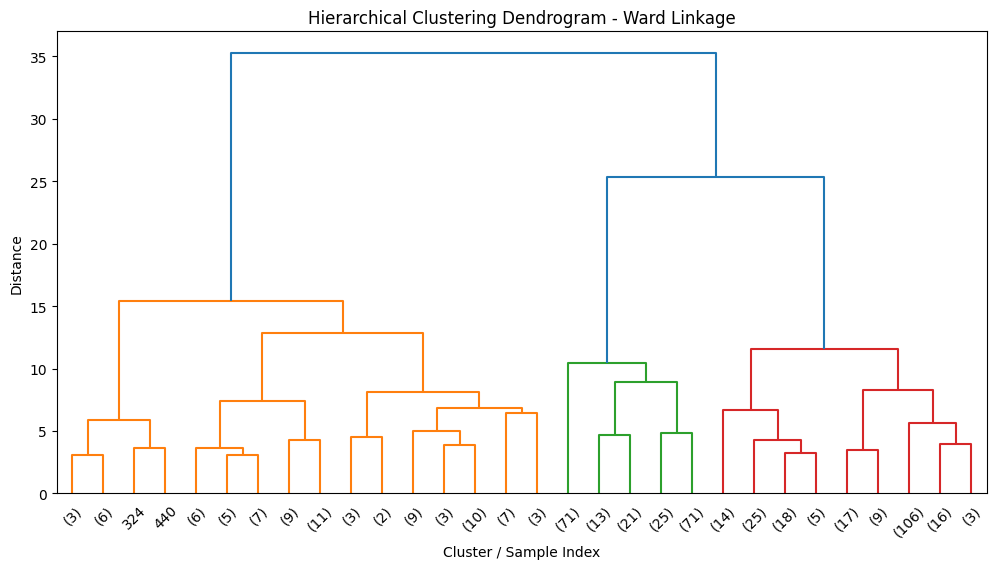

In [19]:
# Dendrogram using Ward linkage

ward_linkage = linkage(
    dendrogram_sample,
    method='ward'
)

plt.figure(figsize=(12, 6))

dendrogram(
    ward_linkage,
    truncate_mode='lastp',
    p=30
)

plt.title("Hierarchical Clustering Dendrogram - Ward Linkage")
plt.xlabel("Cluster / Sample Index")
plt.ylabel("Distance")

plt.show()

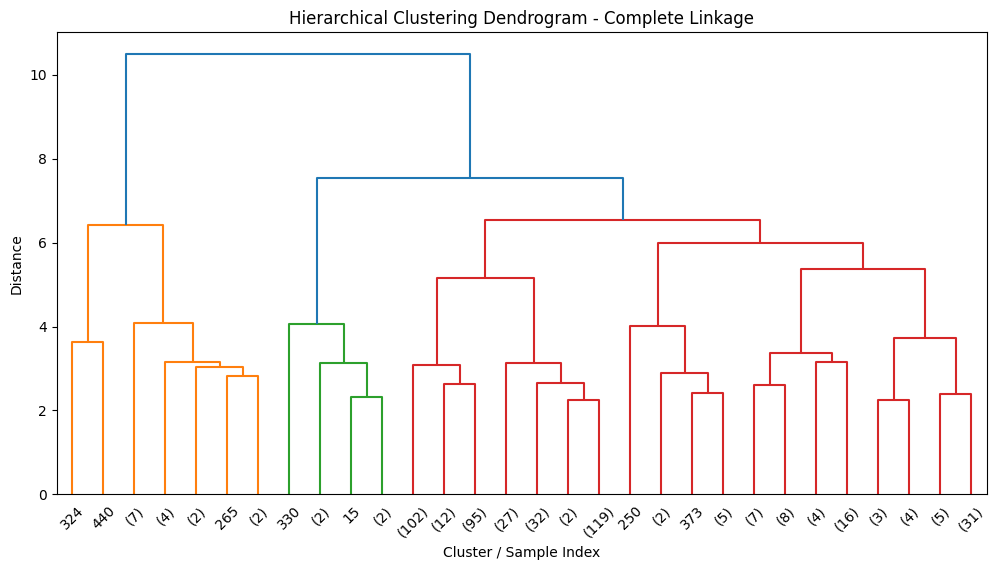

In [20]:
# Dendrogram using Complete linkage

complete_linkage = linkage(
    dendrogram_sample,
    method='complete'
)

plt.figure(figsize=(12, 6))

dendrogram(
    complete_linkage,
    truncate_mode='lastp',
    p=30
)

plt.title("Hierarchical Clustering Dendrogram - Complete Linkage")
plt.xlabel("Cluster / Sample Index")
plt.ylabel("Distance")

plt.show()

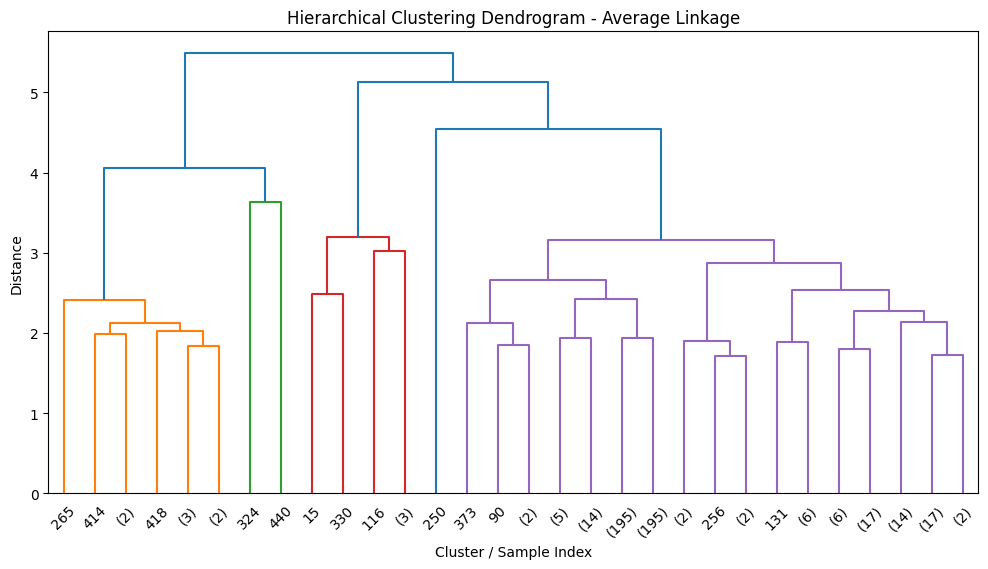

In [21]:
# Dendrogram using Average linkage

average_linkage = linkage(
    dendrogram_sample,
    method='average'
)

plt.figure(figsize=(12, 6))

dendrogram(
    average_linkage,
    truncate_mode='lastp',
    p=30
)

plt.title("Hierarchical Clustering Dendrogram - Average Linkage")
plt.xlabel("Cluster / Sample Index")
plt.ylabel("Distance")

plt.show()

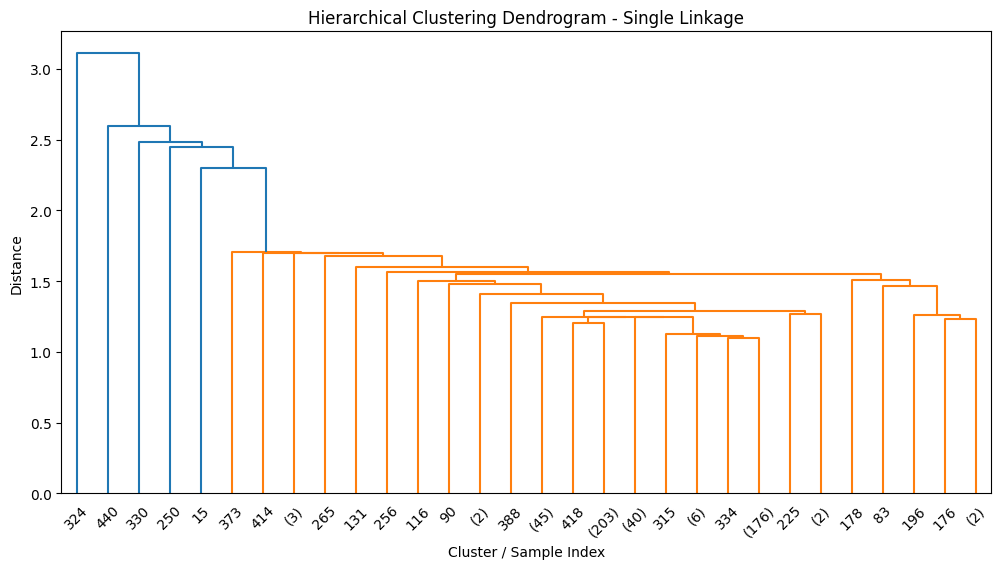

In [22]:
# Dendrogram using Single linkage

single_linkage = linkage(
    dendrogram_sample,
    method='single'
)

plt.figure(figsize=(12, 6))

dendrogram(
    single_linkage,
    truncate_mode='lastp',
    p=30
)

plt.title("Hierarchical Clustering Dendrogram - Single Linkage")
plt.xlabel("Cluster / Sample Index")
plt.ylabel("Distance")

plt.show()

### Observation

The dendrograms were generated using four linkage strategies: **Ward, Complete, Average, and Single linkage**.

The linkage strategy affects the way distances between clusters are calculated and therefore changes the hierarchical structure produced by the algorithm.

The dendrograms provide a visual comparison of the different merging structures. The final linkage strategy will be selected by comparing the clustering evaluation metrics on the complete dataset rather than relying only on visual inspection of the dendrograms.

### 6.2 Comparing Agglomerative Linkage Strategies

The four linkage strategies are evaluated using the same number of clusters selected for K-Means (`k = 5`).

The three mandatory clustering metrics are calculated for each linkage strategy:

- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Index

In [23]:
# Compare Agglomerative Clustering linkage strategies

linkage_methods = ['ward', 'complete', 'average', 'single']

linkage_results = []

for method in linkage_methods:
    
    agglomerative = AgglomerativeClustering(
        n_clusters=5,
        linkage=method
    )
    
    labels = agglomerative.fit_predict(X_scaled)
    
    silhouette = silhouette_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    
    linkage_results.append({
        'Linkage': method,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': davies_bouldin,
        'Calinski-Harabasz Index': calinski_harabasz
    })

linkage_results_df = pd.DataFrame(linkage_results)

linkage_results_df

,Linkage,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,ward,0.370919,1.074210,4200.582131
1,complete,0.853435,0.702750,870.305084
2,average,0.904477,0.334633,500.393132
3,single,0.907375,0.074939,302.310817


### Observation

The four Agglomerative Clustering linkage strategies produced different clustering quality measures.

- **Ward linkage** achieved the highest Calinski-Harabasz Index of **4200.5821**, indicating strong between-cluster separation relative to within-cluster dispersion according to this metric.
- **Complete linkage** achieved a Silhouette Score of **0.8534** and a Davies-Bouldin Index of **0.7028**.
- **Average linkage** improved the Silhouette Score to **0.9045** and reduced the Davies-Bouldin Index to **0.3346**.
- **Single linkage** achieved the highest Silhouette Score of **0.9074** and the lowest Davies-Bouldin Index of **0.0749**.

Considering the Silhouette Score and Davies-Bouldin Index together, **Single linkage** provides the strongest cluster cohesion and separation among the evaluated linkage strategies. Therefore, **Single linkage is selected for the final Agglomerative Clustering model**.

The Calinski-Harabasz Index is highest for Ward linkage, showing that the three evaluation metrics do not identify the same linkage strategy as optimal. Therefore, the final selection is based on the overall metric comparison rather than a single metric.

### 6.3 Final Agglomerative Clustering Model

Based on the comparison of the four linkage strategies, **Single linkage** is selected for the final Agglomerative Clustering model.

The model is fitted using the complete standardized dataset with **5 clusters**.

In [24]:
final_agglomerative = AgglomerativeClustering(
    n_clusters=5,
    linkage='single'
)

agglomerative_labels = final_agglomerative.fit_predict(X_scaled)

print("Number of clusters:", 5)
print("Linkage:", "single")
print("Cluster labels:", np.unique(agglomerative_labels))

Number of clusters: 5
Linkage: single
Cluster labels: [0 1 2 3 4]


In [25]:
agglomerative_cluster_counts = (
    pd.Series(agglomerative_labels)
    .value_counts()
    .sort_index()
)

agglomerative_cluster_counts

0    13315
1        2
2        1
3        1
4        1
Name: count, dtype: int64

### Observation

Although Single linkage produced the highest Silhouette Score and the lowest Davies-Bouldin Index, its cluster distribution reveals a severe imbalance. Almost all observations (**13,315 out of 13,320**) were assigned to a single cluster, while the remaining four clusters contained only 1–2 observations each.

This indicates a **chaining effect**, which is a known characteristic of Single linkage where observations can be progressively connected through nearby points.

Therefore, Single linkage is not considered suitable for the final clustering solution despite its favorable metric values.

**Ward linkage** provides a more meaningful clustering structure because it avoids this extreme cluster imbalance and also achieved the highest Calinski-Harabasz Index. Therefore, **Ward linkage is selected for the final Agglomerative Clustering model**.

In [26]:
final_agglomerative = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

agglomerative_labels = final_agglomerative.fit_predict(X_scaled)

print("Number of clusters:", 5)
print("Linkage:", "ward")
print("Cluster labels:", np.unique(agglomerative_labels))

Number of clusters: 5
Linkage: ward
Cluster labels: [0 1 2 3 4]


In [27]:
agglomerative_cluster_counts = (
    pd.Series(agglomerative_labels)
    .value_counts()
    .sort_index()
)

agglomerative_cluster_counts

0      40
1    1450
2    6069
3    2095
4    3666
Name: count, dtype: int64

### Observation

The final Agglomerative Clustering model using **Ward linkage** produced five clusters with the following distribution:

- Cluster 0: **40 observations**
- Cluster 1: **1,450 observations**
- Cluster 2: **6,069 observations**
- Cluster 3: **2,095 observations**
- Cluster 4: **3,666 observations**

Compared with Single linkage, Ward linkage produces a substantially more meaningful distribution of observations across clusters and avoids the extreme chaining effect observed with Single linkage.

Therefore, **Ward linkage with 5 clusters is retained as the final Agglomerative Clustering configuration**.

### 6.4 Agglomerative Clustering Evaluation

The final Agglomerative Clustering model is evaluated using the three mandatory clustering metrics:

- **Silhouette Score**
- **Davies-Bouldin Index**
- **Calinski-Harabasz Index**

These metrics will be compared with the K-Means results to determine which clustering approach provides a better overall structure for the dataset.

In [28]:
agglomerative_silhouette = silhouette_score(
    X_scaled,
    agglomerative_labels
)

agglomerative_davies_bouldin = davies_bouldin_score(
    X_scaled,
    agglomerative_labels
)

agglomerative_calinski_harabasz = calinski_harabasz_score(
    X_scaled,
    agglomerative_labels
)

print("Agglomerative Clustering Metrics")
print("-" * 35)
print(f"Silhouette Score: {agglomerative_silhouette:.4f}")
print(f"Davies-Bouldin Index: {agglomerative_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {agglomerative_calinski_harabasz:.4f}")

Agglomerative Clustering Metrics
-----------------------------------
Silhouette Score: 0.3709
Davies-Bouldin Index: 1.0742
Calinski-Harabasz Index: 4200.5821


### Observation

The final Agglomerative Clustering model using Ward linkage and 5 clusters achieved:

- **Silhouette Score:** 0.3709
- **Davies-Bouldin Index:** 1.0742
- **Calinski-Harabasz Index:** 4200.5821

When compared with K-Means using the same number of clusters, K-Means achieved a higher Silhouette Score and Calinski-Harabasz Index and a lower Davies-Bouldin Index.

Therefore, based on the three clustering evaluation metrics, **K-Means provides a slightly better overall clustering structure for this dataset**.

## 7. Cluster Visualization Using PCA

To visualize the high-dimensional clustering results, Principal Component Analysis (PCA) is used to reduce the five standardized clustering features to two principal components.

The same PCA transformation is used to visualize both K-Means and Agglomerative Clustering results.

The PCA visualization is used only for interpretation and visualization; the clustering models were fitted using the complete standardized feature space.

In [29]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original feature dimensions:", X_scaled.shape[1])
print("PCA dimensions:", X_pca.shape[1])
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Original feature dimensions: 5
PCA dimensions: 2
Explained variance ratio: [0.52387676 0.1907256 ]
Total explained variance: 0.7146023557544903


### Observation

PCA reduced the original **5-dimensional feature space to 2 principal components** for visualization.

- Principal Component 1 explains **52.39%** of the variance.
- Principal Component 2 explains **19.07%** of the variance.
- Together, the two components explain **71.46%** of the total variance.

Therefore, the two-dimensional PCA representation retains a substantial portion of the information contained in the original standardized feature space and is suitable for visualizing the clustering structure.

### 7.1 K-Means Cluster Visualization

The K-Means cluster assignments are visualized using the first two principal components obtained from PCA.

Each point represents a property, and the points are colored according to their assigned K-Means cluster.

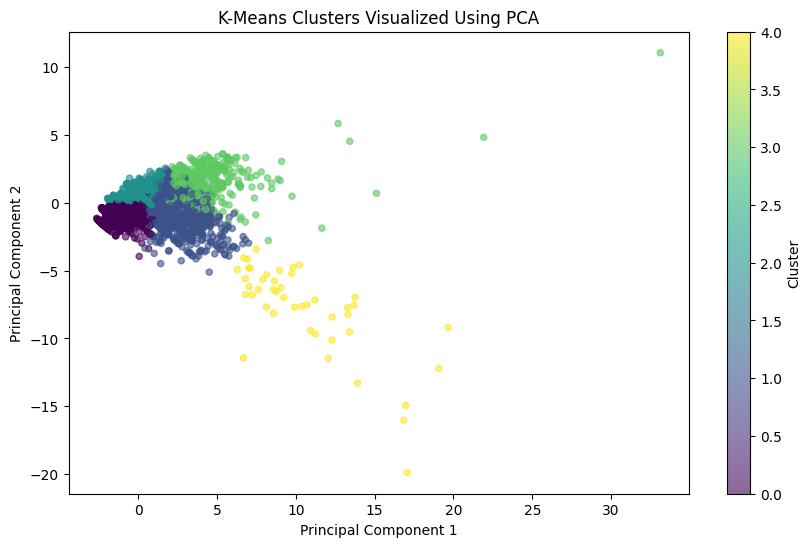

In [30]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    s=20,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized Using PCA")
plt.colorbar(label="Cluster")

plt.show()

### 7.2 Agglomerative Cluster Visualization

The final Agglomerative Clustering assignments using Ward linkage are visualized using the first two principal components obtained from PCA.

Each point represents a property, and the points are colored according to their assigned Agglomerative cluster.

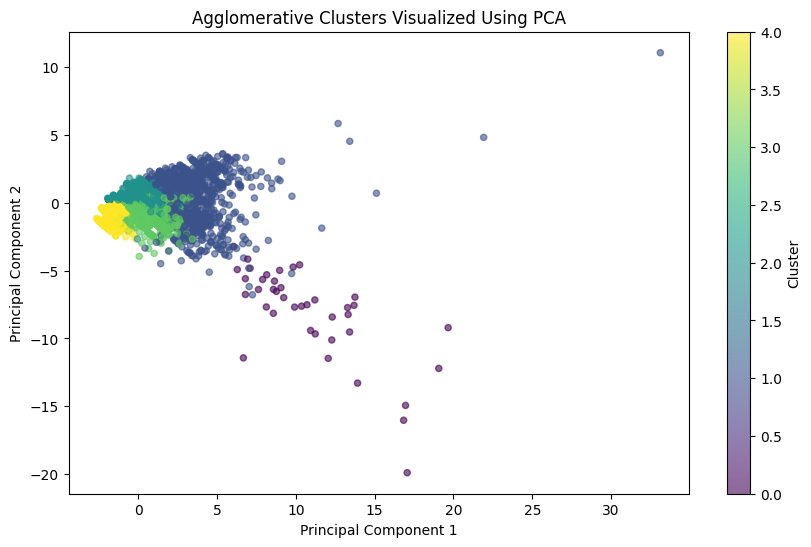

In [31]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=agglomerative_labels,
    s=20,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Agglomerative Clusters Visualized Using PCA")
plt.colorbar(label="Cluster")

plt.show()

### Observation

The PCA visualization provides a two-dimensional representation of the Agglomerative Clustering results using Ward linkage.

The clusters show separation along the principal component axes, although some overlap is visible between groups. The visualization provides a qualitative view of the clustering structure and complements the quantitative evaluation obtained from the Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index.

PCA is used only for visualization; the clustering models were fitted using all five standardized features.

## 8. Final Clustering Model Comparison

The final K-Means and Agglomerative Clustering models are compared using the three mandatory clustering evaluation metrics.

For all metrics:

- Higher **Silhouette Score** indicates better-defined clusters.
- Lower **Davies-Bouldin Index** indicates better cluster separation.
- Higher **Calinski-Harabasz Index** generally indicates better-defined clusters.

The comparison is performed using the complete standardized dataset.

In [32]:
final_clustering_results = pd.DataFrame({
    'Algorithm': [
        'K-Means',
        'Agglomerative'
    ],
    'Configuration': [
        'k=5',
        'k=5, Ward linkage'
    ],
    'Silhouette Score': [
        kmeans_silhouette,
        agglomerative_silhouette
    ],
    'Davies-Bouldin Index': [
        kmeans_davies_bouldin,
        agglomerative_davies_bouldin
    ],
    'Calinski-Harabasz Index': [
        kmeans_calinski_harabasz,
        agglomerative_calinski_harabasz
    ]
})

final_clustering_results

,Algorithm,Configuration,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,k=5,0.398225,1.046219,4931.451452
1,Agglomerative,"k=5, Ward linkage",0.370919,1.074210,4200.582131


### Observation

The final clustering comparison shows that **K-Means with 5 clusters** performs slightly better than **Agglomerative Clustering with 5 clusters using Ward linkage** across all three evaluation metrics.

K-Means achieved:

- Silhouette Score: **0.3982**
- Davies-Bouldin Index: **1.0462**
- Calinski-Harabasz Index: **4931.4515**

Agglomerative Clustering achieved:

- Silhouette Score: **0.3709**
- Davies-Bouldin Index: **1.0742**
- Calinski-Harabasz Index: **4200.5821**

Therefore, **K-Means with 5 clusters is selected as the preferred clustering approach** for this dataset based on the overall quantitative evaluation.

The Agglomerative model using Ward linkage still provides a useful alternative hierarchical clustering structure.

### 8.1 Saving Final Clustering Results

The final clustering evaluation results are saved as a CSV file for reproducibility and further analysis.

In [33]:
final_clustering_results.to_csv(
    "../data/clustering_final_results.csv",
    index=False
)

print("Final clustering results saved successfully.")

Final clustering results saved successfully.


## 9. Cluster Profiling

To interpret the clusters produced by K-Means, the mean values of the original numerical features are calculated for each cluster.

The profile includes:

- Total square footage
- Number of bedrooms
- Number of bathrooms
- Number of balconies
- Property price

This analysis helps identify the characteristics associated with each cluster.

In [34]:
cluster_profile = data[cluster_features].copy()

cluster_profile['Cluster'] = kmeans_labels

cluster_profile = (
    cluster_profile
    .groupby('Cluster')
    .mean()
    .round(2)
)

cluster_profile

,total_sqft_num,bhk,bath,balcony,price
Cluster,,,,,
0,1156.53,2.22,2.06,0.84,67.27
1,2822.93,4.03,4.19,1.81,292.18
2,1406.94,2.60,2.44,2.20,79.99
3,1972.64,7.42,7.19,1.92,191.78
4,13260.29,4.67,5.27,2.07,1621.44


### Observation

The cluster profiles show differences in the average property characteristics across the five K-Means clusters.

The clusters can be interpreted based on their average property size, bedroom count, bathroom count, balcony count, and price.

These profiles provide a practical interpretation of the numerical patterns identified by the clustering algorithm. The clusters represent groups of properties with similar quantitative characteristics rather than predefined categories.

### 9.1 Cluster Size and Profile Summary

The number of properties and their average characteristics are combined to provide an overall summary of the K-Means clusters.

In [35]:
cluster_summary = cluster_profile.copy()

cluster_summary.insert(
    0,
    'Number of Properties',
    cluster_counts
)

cluster_summary

,Number of Properties,total_sqft_num,bhk,bath,balcony,price
Cluster,,,,,,
0,5252,1156.53,2.22,2.06,0.84,67.27
1,1811,2822.93,4.03,4.19,1.81,292.18
2,5791,1406.94,2.60,2.44,2.20,79.99
3,421,1972.64,7.42,7.19,1.92,191.78
4,45,13260.29,4.67,5.27,2.07,1621.44


### Observation

The K-Means cluster profiles show clear differences in the characteristics of the properties:

- **Cluster 0** contains **5,252 properties** and represents relatively smaller properties, with an average area of **1,156.53 sqft**, **2.22 BHK**, **2.06 bathrooms**, **0.84 balconies**, and a price of approximately **₹67.27 lakh**.
- **Cluster 1** contains **1,811 properties** and represents larger and more expensive properties, with an average area of **2,822.93 sqft**, **4.03 BHK**, **4.19 bathrooms**, **1.81 balconies**, and a price of approximately **₹292.18 lakh**.
- **Cluster 2** is the largest cluster with **5,791 properties**. It represents moderately sized properties with an average area of **1,406.94 sqft**, **2.60 BHK**, **2.44 bathrooms**, **2.20 balconies**, and a price of approximately **₹79.99 lakh**.
- **Cluster 3** contains **421 properties** and is characterized by a relatively high number of bedrooms and bathrooms. Its average area is **1,972.64 sqft**, with **7.42 BHK**, **7.19 bathrooms**, **1.92 balconies**, and a price of approximately **₹191.78 lakh**.
- **Cluster 4** contains only **45 properties** and represents highly distinctive, very large and expensive properties. The average area is **13,260.29 sqft**, with **4.67 BHK**, **5.27 bathrooms**, **2.07 balconies**, and a price of approximately **₹1,621.44 lakh**.

Overall, the clustering results identify groups of properties with substantially different size, room configuration, and price characteristics. Cluster 4 is particularly distinct because of its extremely large average area and very high average price.

## 10. Final Clustering Conclusion

K-Means and Agglomerative Hierarchical Clustering were applied to the standardized numerical property features.

For K-Means, the Elbow Method was used to select **5 clusters**. The resulting model achieved a Silhouette Score of **0.3982**, a Davies-Bouldin Index of **1.0462**, and a Calinski-Harabasz Index of **4931.4515**.

For Agglomerative Hierarchical Clustering, four linkage strategies were compared using dendrograms and clustering metrics. Single linkage produced very high Silhouette and low Davies-Bouldin values but resulted in an extreme chaining effect, with almost all observations assigned to a single cluster. Therefore, Ward linkage was selected as the final Agglomerative configuration because it produced a substantially more balanced cluster distribution.

The final Ward Agglomerative model achieved a Silhouette Score of **0.3709**, a Davies-Bouldin Index of **1.0742**, and a Calinski-Harabasz Index of **4200.5821**.

Based on the overall comparison of the three mandatory evaluation metrics, **K-Means with 5 clusters is selected as the preferred clustering model**.

PCA was used to visualize the clusters in two dimensions. The first two principal components explained **71.46% of the total variance**, providing a useful two-dimensional representation of the original five-dimensional feature space.

The cluster profiling further showed that the identified groups represent properties with different combinations of area, bedroom count, bathroom count, balcony count, and price.